<a href="https://www.kaggle.com/code/cartelsmith/step-by-step-random-forest-parameter-tuning?scriptVersionId=336586358" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
from ast import parse

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Teen_Mental_Health_Dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sunil123kumar/social-media-impact-on-mental-health",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot  as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

/tmp/ipykernel_58/2956622485.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [2]:
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


None

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [3]:



print(f'Here are the # of unique values per column:\n{df.nunique()}')
missing = df.isna().sum()
print('---' * 50)
print(f'\nHere are the missing values per column:\n{missing}')
print('---' * 50)

# Identifying column types
to_cat =df.select_dtypes(include='object').columns.tolist()
df[to_cat] = df[to_cat].astype('category')

numeric_cols = df.select_dtypes(include='number')
category_cols = df.select_dtypes(exclude='number')

Here are the # of unique values per column:
age                           7
gender                        2
daily_social_media_hours     71
platform_usage                3
sleep_hours                  51
screen_time_before_sleep     26
academic_performance        201
physical_activity            21
social_interaction_level      3
stress_level                 10
anxiety_level                10
addiction_level              10
depression_label              2
dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------

Here are the missing values per column:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addic

# Machine Learning

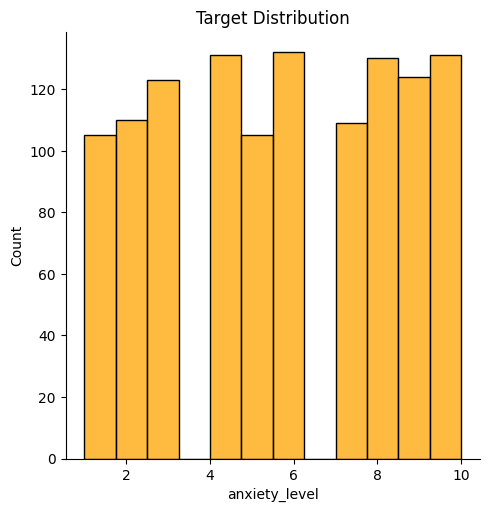

In [4]:
# Splitting data into features and target
target = df['anxiety_level'] # Let's precit the anxiety level (Multiclass)
features = df.drop(columns='anxiety_level')

sns.displot(target, color="orange") # Viewing Target Distribution
plt.title('Target Distribution')
plt.show()

# Splitting data into training and testing set 
X_train,x_test, y_train,y_test = train_test_split(features,target, random_state=12,
                                                  stratify=target, test_size=.25)

In [5]:
# Importing model
from sklearn.ensemble import RandomForestRegressor


# OneHotEncoding Categorical Cols and Ordinal Encoding others
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

ord_cols = ['stress_level','addiction_level']

transformer = ColumnTransformer(transformers=[('cat',OneHotEncoder(),to_cat),
                                              ('ord',OrdinalEncoder(),ord_cols)],
                                              remainder= 'passthrough'
                                )

# Making a pipeline that transforms incoming data, then runs it through the regressor
from sklearn.pipeline import Pipeline

pipe = Pipeline(steps=[('preprocessing', transformer),
                       ('regressor', RandomForestRegressor(random_state=12))])

In [6]:
# Initial model runs

pipe.fit(X_train,y_train)
y_pred= pipe.predict(x_test)

In [7]:
# Evaluating Model
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

mae= mean_absolute_error(y_true=y_test,y_pred=y_pred)
r2 = r2_score(y_true=y_test,y_pred=y_pred)
rms = root_mean_squared_error(y_true=y_test,y_pred=y_pred)

eval_metrics = {'mae': mae,
                'r2': r2,
                'rms': rms
                }

print(f'The scores are:\n{eval_metrics}')

The scores are:
{'mae': 2.4874, 'r2': -0.030073317675890943, 'rms': 2.8993545258672087}


In [8]:
# Parameter optimization using Gridsearch with Cross Validation
from sklearn.model_selection import GridSearchCV


param_grid = {'regressor__n_estimators': [50,75,100],
              'regressor__max_depth':[None,2,3,4,5],
              'regressor__warm_start':[True, False],
              'regressor__max_leaf_nodes':[None,10,20,50]
              }


scorers = ['neg_mean_absolute_percentage_error','neg_mean_absolute_error',
           'neg_mean_squared_error','r2']

# Configuring GridSearch
grid_search = GridSearchCV(pipe, param_grid=param_grid, refit='neg_mean_absolute_error',
                           scoring=scorers, cv=3,verbose=1)

grid_search.fit(X_train,y_train)

Fitting 3 folds for each of 120 candidates, totalling 360 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(),
                                                                         ['gender',
                                                                          'platform_usage',
                                                                          'social_interaction_level']),
                                                                        ('ord',
                                                                         OrdinalEncoder(),
                                                                         ['stress_level',
                                                                          'addiction_level'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=12))]),
             param_grid={'regressor__max_depth': [None, 2, 3, 4, 5],
                         'regressor__max_leaf_nodes': [None, 10, 20, 50],
                         'regressor__n_estimators': [50, 75, 100],
                         'regressor__warm_start': [True, False]},
             refit='neg_mean_absolute_error',
             scoring=['neg_mean_absolute_percentage_error',
                      'neg_mean_absolute_error', 'neg_mean_squared_error',
                      'r2'],
             verbose=1)

In [9]:
# Evaluating Model
best_model = grid_search.best_estimator_

print(f'🥁🥁🥁...And the best parameters for this model are:\n {grid_search.best_params_}')
print(f'\n\nBest MAE: {-grid_search.best_score_:.2f}')

🥁🥁🥁...And the best parameters for this model are:
 {'regressor__max_depth': 3, 'regressor__max_leaf_nodes': 10, 'regressor__n_estimators': 100, 'regressor__warm_start': True}


Best MAE: 2.43
